# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Task 1: Problem Identification

The dataset represents a **Image Classification** Computer Vision type of problem
The reasons for this are as follows:
1. Each image is assigned exactly one class label (`normal`, `scratch`, `dent`, or `stain`). There are no bounding boxes, pixel-level masks, or multiple object annotations in the images.
2. The task is to determine *what type* of defect (if any) is present on the product surface (one of the 4 types for which sample images are provided), not *where* on the object it is located. This rules out object detection (which requires bounding boxes) and segmentation (which requires pixel-level masks).
3. Each image belongs to exactly one category. The folder structure and `labels.csv` confirm a clean one-to-one mapping between images and class labels.
4. The entire image represents a single product surface, and the model must classify the overall image into one of four categories.

## Task 2: Dataset Exploration

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = os.path.join('Data_Sets', 'part_2_cnn_computer_vision')
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
LABELS_CSV = os.path.join(BASE_DIR, 'labels.csv')

df = pd.read_csv(LABELS_CSV)
print(f"Total images in labels.csv: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Total images in labels.csv: 480

Columns: ['filename', 'class']

First 5 rows:


,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [43]:
# Number of unique classes
classes = sorted(df['class'].unique())
num_classes = len(classes)
print(f"Number of classes: {num_classes}")
print(f"Class names: {classes}")

# Number of images per class
class_counts = df['class'].value_counts().sort_index()
print("Images per class:")
print(class_counts)
print(f"\nTotal images: {class_counts.sum()}")

Number of classes: 4
Class names: ['dent', 'normal', 'scratch', 'stain']
Images per class:
class
dent       120
normal     120
scratch    120
stain      120
Name: count, dtype: int64

Total images: 480


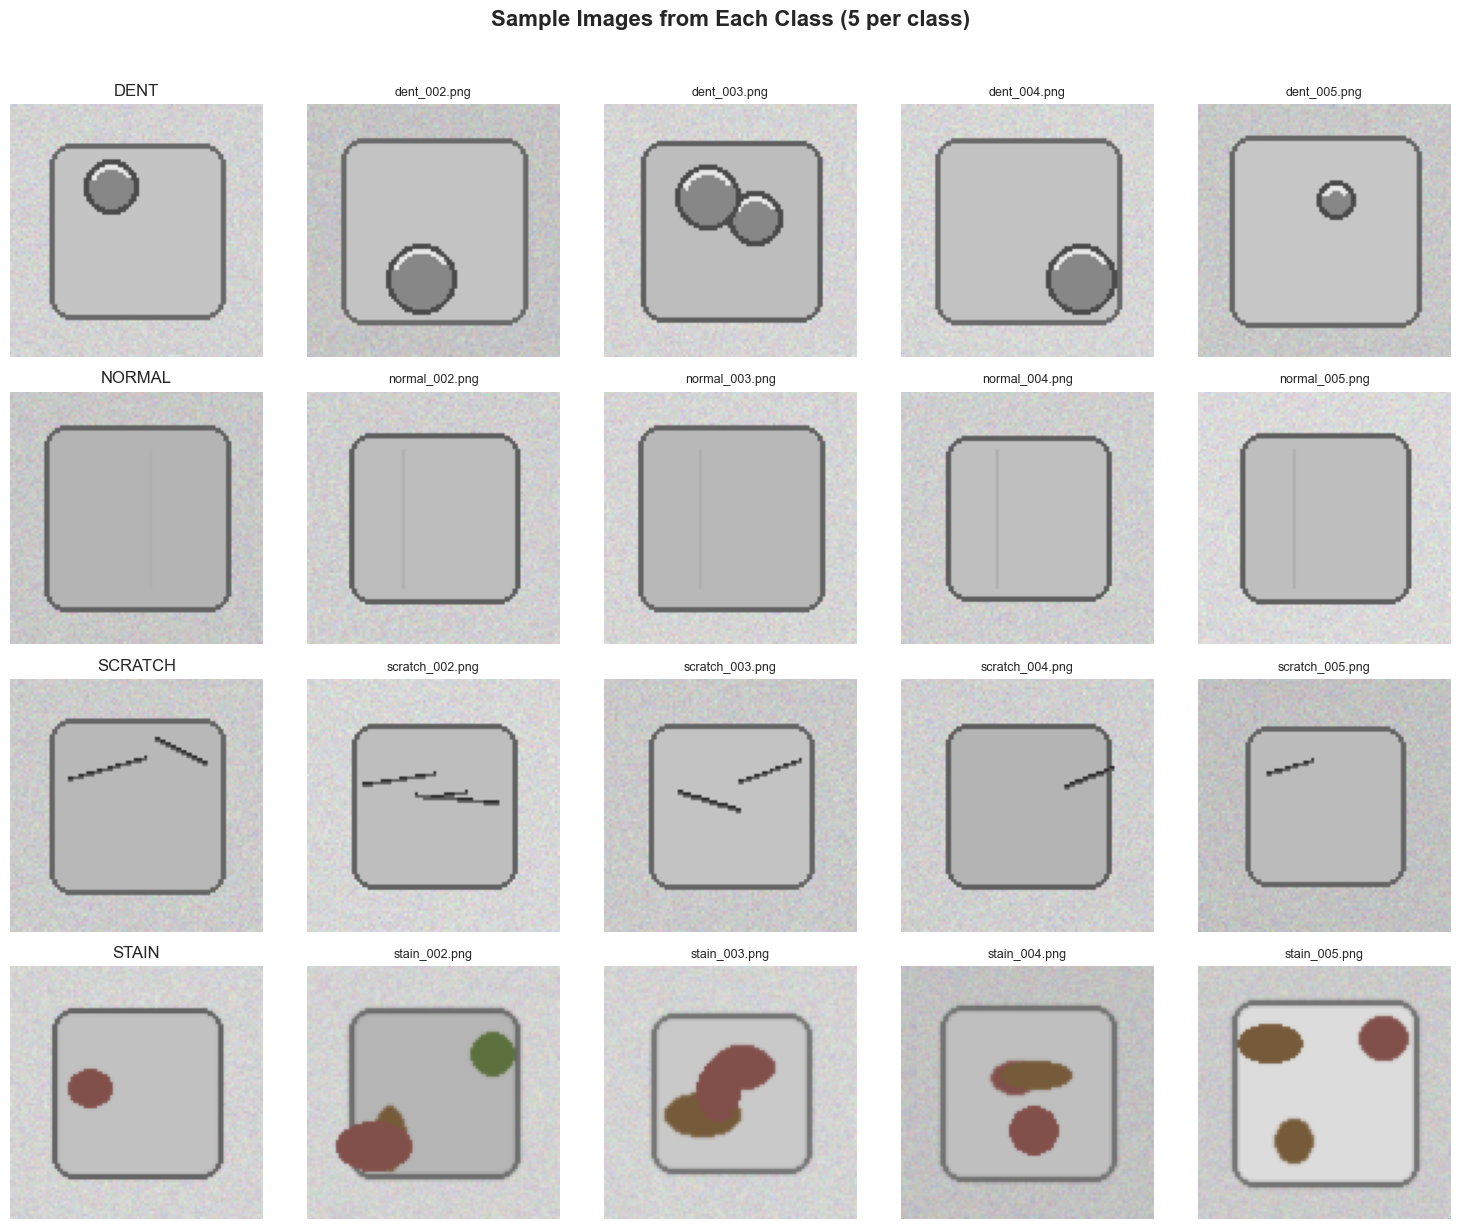

In [44]:
# Showing 5 sample images from each class

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample Images from Each Class (5 per class)', fontsize=16, fontweight='bold', y=1.02)

for row_idx, cls in enumerate(classes):
    cls_dir = os.path.join(IMAGES_DIR, cls)
    img_files = sorted([f for f in os.listdir(cls_dir) if f.endswith('.png')])[:5]
    
    for col_idx, img_file in enumerate(img_files):
        img_path = os.path.join(cls_dir, img_file)
        img = Image.open(img_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(f'{cls.upper()}')
        else:
            axes[row_idx, col_idx].set_title(img_file, fontsize=9)

plt.tight_layout()
plt.show()


In [45]:
# Showing image dimensions

dimensions = []
modes = []

for _, row in df.iterrows():
    img_path = os.path.join(BASE_DIR, row['filename'])
    img = Image.open(img_path)
    dimensions.append(img.size)  # (width, height)
    modes.append(img.mode)

unique_dims = set(dimensions)
unique_modes = set(modes)

print(f"Unique image dimensions (WxH): {unique_dims}")
print(f"Image color modes: {unique_modes}")
print(f"\nAll images are {'the same size' if len(unique_dims) == 1 else 'different sizes'}")

w, h = dimensions[0]
print(f"Image dimensions: {w} x {h} pixels")
print(f"Color channels: 3 (RGB)")
print(f"Input shape per image: ({h}, {w}, 3)")

Unique image dimensions (WxH): {(96, 96)}
Image color modes: {'RGB'}

All images are the same size
Image dimensions: 96 x 96 pixels
Color channels: 3 (RGB)
Input shape per image: (96, 96, 3)


In [46]:
# Analysing imbalances in the dataset

print("============================")
print("DATASET IMBALANCE ANALYSIS")
print("============================")

total = len(df)
print(f"\nTotal images: {total}")
print(f"Number of classes: {num_classes}")
print(f"Expected per class (balanced): {total // num_classes}")
print()

for cls in classes:
    count = class_counts[cls]
    pct = count / total * 100
    print(f"  {cls:>10s}: {count:4d} images ({pct:.1f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio == 1.0:
    print("\nConclusion: The dataset is PERFECTLY BALANCED.")
    print("All classes have exactly the same number of images.")
    print("No resampling, class weighting, or data augmentation strategies are needed to handle imbalance.")
elif imbalance_ratio < 1.5:
    print("\nConclusion: The dataset is approximately balanced (ratio < 1.5).")
else:
    print(f"\nConclusion: The dataset is IMBALANCED (ratio = {imbalance_ratio:.2f}).")
    print("Consider using class weights, oversampling, or data augmentation.")

DATASET IMBALANCE ANALYSIS

Total images: 480
Number of classes: 4
Expected per class (balanced): 120

        dent:  120 images (25.0%)
      normal:  120 images (25.0%)
     scratch:  120 images (25.0%)
       stain:  120 images (25.0%)

Imbalance ratio (max/min): 1.00

Conclusion: The dataset is PERFECTLY BALANCED.
All classes have exactly the same number of images.
No resampling, class weighting, or data augmentation strategies are needed to handle imbalance.


## Task 3: Image Preprocessing

In [47]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory  # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Loading and resizing all images

IMG_SIZE = 64

images = []
labels = []

for _, row in df.iterrows():
    img_path = os.path.join(BASE_DIR, row['filename'])
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    images.append(np.array(img))
    labels.append(row['class'])

X = np.array(images)
y_text = np.array(labels)

print(f"Loaded image array shape: {X.shape}")
print(f"Data type: {X.dtype}")
print(f"Pixel value range: [{X.min()}, {X.max()}]")
print(f"Labels array shape: {y_text.shape}")

Loaded image array shape: (480, 64, 64, 3)
Data type: uint8
Pixel value range: [32, 253]
Labels array shape: (480,)


In [48]:
# Encoding labels to integers using One-Hot Encoding

le = LabelEncoder()
y_int = le.fit_transform(y_text)
y = tf.keras.utils.to_categorical(y_int, num_classes=4)

print("Label encoding mapping:")
for i, cls_name in enumerate(le.classes_):
    print(f"  {cls_name} -> {i}")

print(f"\nInteger labels shape: {y_int.shape}")
print(f"One-hot encoded shape: {y.shape}")
print(f"\nExample — label '{y_text[0]}' -> integer {y_int[0]} -> one-hot {y[0]}")

Label encoding mapping:
  dent -> 0
  normal -> 1
  scratch -> 2
  stain -> 3

Integer labels shape: (480,)
One-hot encoded shape: (480, 4)

Example — label 'normal' -> integer 1 -> one-hot [0. 1. 0. 0.]


In [50]:
# normalizing pixel values to [0, 1] to bring all pixels to a common scale

X_normalized = X.astype('float32') / 255.0

print(f"Before normalization — dtype: {X.dtype}, range: [{X.min()}, {X.max()}]")
print(f"After normalization  — dtype: {X_normalized.dtype}, range: [{X_normalized.min():.1f}, {X_normalized.max():.1f}]")
print(f"Shape: {X_normalized.shape}")

Before normalization — dtype: uint8, range: [32, 253]
After normalization  — dtype: float32, range: [0.1, 1.0]
Shape: (480, 64, 64, 3)


In [60]:
#Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y_int
)

print("==========================")
print("TRAIN-TEST SPLIT SUMMARY")
print("==========================")
print(f"\nTraining set:  {X_train.shape[0]} images  ({X_train.shape[0]/len(X_normalized)*100:.0f}%)")
print(f"Testing set:   {X_test.shape[0]} images  ({X_test.shape[0]/len(X_normalized)*100:.0f}%)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

# verifying the class distribution in the training and testing sets

train_class_counts = np.argmax(y_train, axis=1)
test_class_counts = np.argmax(y_test, axis=1)

train_counts = pd.Series(train_class_counts).map(dict(enumerate(le.classes_))).value_counts().sort_index()
test_counts = pd.Series(test_class_counts).map(dict(enumerate(le.classes_))).value_counts().sort_index()

print()
print("=================================")
print("Class distribution verification:")
print("=================================")
print(f"{'Class':<10} {'Train':>6} {'Test':>6} {'Train%':>8} {'Test%':>8}")
print("-----------------------------------------------")
for cls in le.classes_:
    tr = train_counts[cls]
    te = test_counts[cls]
    print(f"{cls:<10} {tr:>6} {te:>6} {tr/X_train.shape[0]*100:>7.1f}% {te/X_test.shape[0]*100:>7.1f}%")

TRAIN-TEST SPLIT SUMMARY

Training set:  384 images  (80%)
Testing set:   96 images  (20%)

X_train shape: (384, 64, 64, 3)
X_test shape:  (96, 64, 64, 3)
y_train shape: (384, 4)
y_test shape:  (96, 4)

Class distribution verification:
Class       Train   Test   Train%    Test%
-----------------------------------------------
dent           96     24    25.0%    25.0%
normal         96     24    25.0%    25.0%
scratch        96     24    25.0%    25.0%
stain          96     24    25.0%    25.0%


**Data Augmentation:** We have a very balanced dataset - 120 images per class (96 in training data). So Data augmentation may not be needed. However, there is some benefit in augmenting the training data, primarily to improve the diversity of the data set. Test data must remain unchanged. Artificially introducing more diversity in the training data set can help me prevent overfitting, especially since the training data set is small. Also, it will mimic real-world scnearios / variations better. I will augment the training data set by rotating images by 20 deg, zooming 10%, changing brightness of images by 10%, flipping the image.

In [64]:
from tf_keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()  # No augmentation for test set
train_generator = train_datagen.flow(X_train, y_train, batch_size=32, seed=42)
test_generator = test_datagen.flow(X_test, y_test, batch_size=32, seed=42)

print("Training Data Augmentation Generators created:")
print(f"  Batch size: 32")
print(f"  Steps per epoch: {len(X_train) // 32 + (1 if len(X_train) % 32 else 0)}")
print(f"\nTest Data Generator created (no augmentation)")
print(f"  Batch size: 32")
print(f"  Steps: {len(X_test) // 32 + (1 if len(X_test) % 32 else 0)}")

Training Data Augmentation Generators created:
  Batch size: 32
  Steps per epoch: 12

Test Data Generator created (no augmentation)
  Batch size: 32
  Steps: 3


**Image Preprocessing Summary:**
1. All images were resized from 96x96 to **64x64** pixels to reduce computation effort.
2. Pixel values were scaled from [0, 255] to [0.0, 1.0] by dividing by 255 to normalize.
3. One-hot encoder was used to convert text labels to integers for the 4 image categories.
4. Dataset was split through a 80:20 train:test stratified split (balanced representation of all categories)
5. Data augmentation was applied ONLY to the train data set. Test data set maintained as-is

## Task 4: CNN Model Creation

Building a Convolutional Neural Network using TensorFlow/Keras to classify manufacturing defect images into 4 classes.

In [79]:
from tf_keras.models import Sequential
from tf_keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input)

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(64, (3, 3), activation='tanh', padding='same'), # 2nd conv block : 64 filters
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='tanh'), # Fully connected layer with 128 neurons
    Dropout(0.5), # Dropout for regularization. This will help deal with potential overfitting given the small dataset size.
    Dense(num_classes, activation='softmax') # Output layer with softmax activation
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 64)        0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 32, 32, 64)        256       
 Normalization)                                                  
                                                                 
 flatten (Flatten)           (None, 65536)             0         
                                                                 
 dense (Dense)               (None, 128)               8388736   
                                                                 
 dropout (Dropout)           (None, 128)              

## Task 5: Model Training and Evaluation 

Training and evaluating the CNN model.

In [80]:
# Compiling the model
from tf_keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer:       Adam (lr=0.001)")
print(f"  Loss function:   Categorical Cross-Entropy")
print(f"  Metrics:         Accuracy")
print(f"  Total params:    {model.count_params():,}")


Model compiled successfully!
  Optimizer:       Adam (lr=0.001)
  Loss function:   Categorical Cross-Entropy
  Metrics:         Accuracy
  Total params:    8,391,300


In [81]:
# Training the model on augmented training dataset and validating on the test data set after each epoch

EPOCHS = 50
BATCH_SIZE = 32

history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1
)

print(f"\nTraining completed after {len(history.history['loss'])} epochs")

Epoch 1/50


12/12 [==============================] - 2s 58ms/step - loss: 1.4106 - accuracy: 0.2396 - val_loss: 5.1153 - val_accuracy: 0.2500
Epoch 2/50
12/12 [==============================] - 1s 39ms/step - loss: 1.4094 - accuracy: 0.2865 - val_loss: 5.0229 - val_accuracy: 0.2500
Epoch 3/50
12/12 [==============================] - 1s 42ms/step - loss: 1.4050 - accuracy: 0.2240 - val_loss: 2.6992 - val_accuracy: 0.2500
Epoch 4/50
12/12 [==============================] - 1s 39ms/step - loss: 1.4021 - accuracy: 0.2474 - val_loss: 2.7686 - val_accuracy: 0.2500
Epoch 5/50
12/12 [==============================] - 1s 39ms/step - loss: 1.4067 - accuracy: 0.2474 - val_loss: 1.7111 - val_accuracy: 0.2500
Epoch 6/50
12/12 [==============================] - 0s 37ms/step - loss: 1.4179 - accuracy: 0.2266 - val_loss: 1.5599 - val_accuracy: 0.2500
Epoch 7/50
12/12 [==============================] - 0s 35ms/step - loss: 1.4400 - accuracy: 0.2214 - val_loss: 2.3166 - val_accuracy: 0.2500
Epoch 8/50


In [84]:
# Evaluating the model on the test set (unaugmented)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("=====================")
print("TEST SET EVALUATION")
print("=====================")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)")

TEST SET EVALUATION
Test Loss:     1.5503
Test Accuracy: 0.2500  (25.0%)


In [86]:
# Training history (loss and accuracy curves)

epochs_range = range(1, len(history.history['loss']) + 1)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Best epoch (lowest val_loss): {best_epoch}")
print(f"  Train loss: {history.history['loss'][best_epoch-1]:.4f}  |  Val loss: {history.history['val_loss'][best_epoch-1]:.4f}")
print(f"  Train acc:  {history.history['accuracy'][best_epoch-1]:.4f}  |  Val acc:  {history.history['val_accuracy'][best_epoch-1]:.4f}")

Best epoch (lowest val_loss): 10
  Train loss: 1.4273  |  Val loss: 1.4248
  Train acc:  0.2370  |  Val acc:  0.2500


In [ ]:
# Confusion matrix and classification report

from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)) # was getting a warning about precision being set to 0.0. Added zero_division=0 to handle that. This is probably happening due to the small dataset size.


Confusion Matrix:
[[ 0 24  0  0]
 [ 0 24  0  0]
 [ 0 24  0  0]
 [ 0 24  0  0]]

Classification Report:
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        24
      normal       0.25      1.00      0.40        24
     scratch       0.00      0.00      0.00        24
       stain       0.00      0.00      0.00        24

    accuracy                           0.25        96
   macro avg       0.06      0.25      0.10        96
weighted avg       0.06      0.25      0.10        96

